<a href="https://colab.research.google.com/github/etsub28/ds2/blob/main/financial_inclusion_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [187]:
# dataframe + plotting
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# starter model (we may upgrade later)
from lightgbm import LGBMClassifier

# utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [162]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [188]:
train = pd.read_csv('/content/drive/MyDrive/Train.csv')
test = pd.read_csv('/content/drive/MyDrive/Test.csv')
sample = pd.read_csv('/content/drive/MyDrive/SampleSubmission.csv')

In [189]:
print('train data shape :', train.shape)
print('test data shape :', test.shape)

train data shape : (23524, 13)
test data shape : (10086, 12)


In [165]:
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [166]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


In [167]:
print(train.isnull().sum())

country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64


In [168]:
train['bank_account'].value_counts()

,count
bank_account,
No,20212
Yes,3312


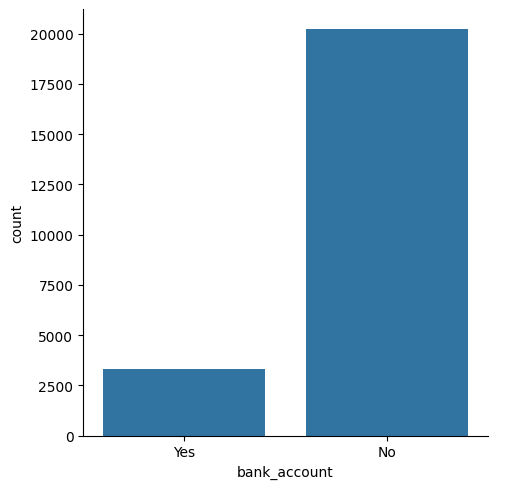

In [169]:
sns.catplot(
    x="bank_account",
    kind="count",
    data=train
);

In [170]:
sample.head()

,unique_id,bank_account
0,uniqueid_1 x Kenya,0
1,uniqueid_2 x Kenya,0
2,uniqueid_3 x Kenya,0
3,uniqueid_4 x Kenya,0
4,uniqueid_5 x Kenya,0


In [171]:
country_rate = pd.crosstab(
    train["country"],
    train["bank_account"],
    normalize='index'
)*100

print(country_rate)

bank_account         No        Yes
country                           
Kenya         74.934080  25.065920
Rwanda        88.517459  11.482541
Tanzania      90.830816   9.169184
Uganda        91.385055   8.614945


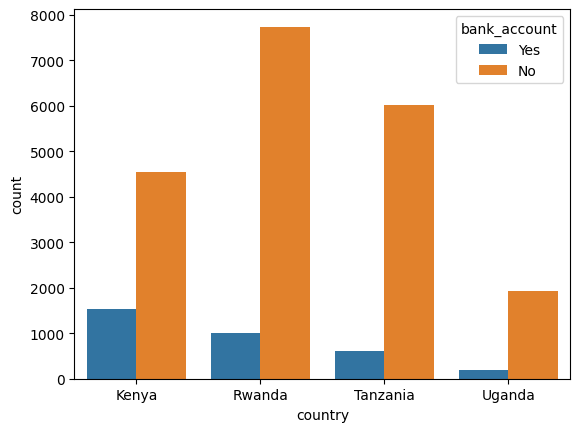

In [172]:
sns.countplot(
    data=train,
    x="country",
    hue="bank_account"
)
plt.show()

In [173]:
pd.crosstab(
    train["location_type"],
    train["bank_account"],
    normalize='index'
)*100

bank_account,No,Yes
location_type,,
Rural,88.349718,11.650282
Urban,82.126130,17.873870


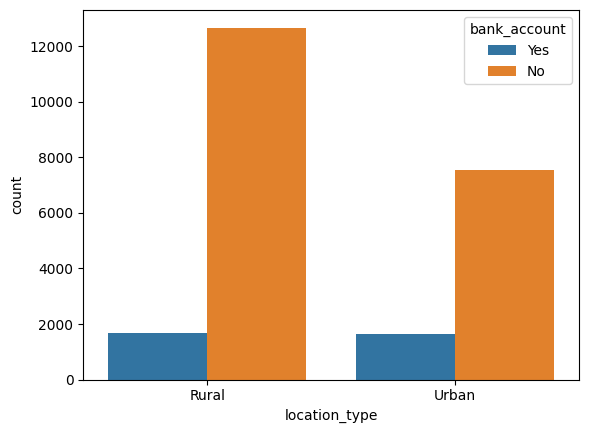

In [174]:
sns.countplot(
    data=train,
    x="location_type",
    hue="bank_account"
)
plt.show()

In [190]:
pd.crosstab(
    train["cellphone_access"],
    train["bank_account"],
    normalize='index'
)*100

bank_account,No,Yes
cellphone_access,,
No,98.286656,1.713344
Yes,81.620259,18.379741


In [209]:
edu = pd.crosstab(
    train["education_level"],
    train["bank_account"],
    normalize='index'
)*100

print(edu.sort_values(1))

bank_account                             0          1
education_level                                      
No formal education              96.101883   3.898117
Primary education                91.454929   8.545071
Secondary education              76.722709  23.277291
Other/Dont know/RTA              68.571429  31.428571
Tertiary education               48.919620  51.080380
Vocational/Specialised training  42.963885  57.036115


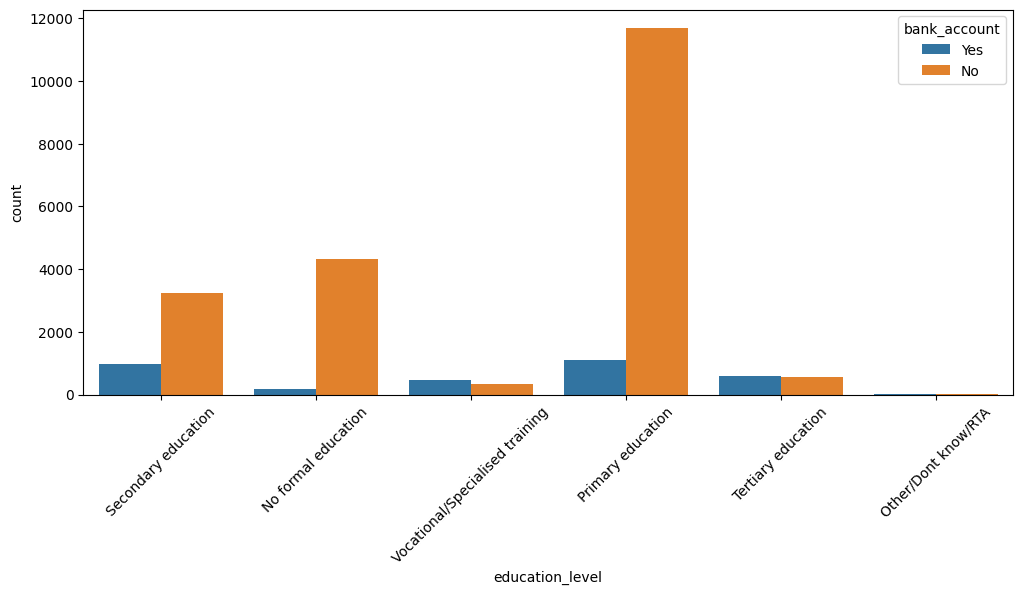

In [192]:
plt.figure(figsize=(12,5))
sns.countplot(
    data=train,
    x="education_level",
    hue="bank_account"
)
plt.xticks(rotation=45)
plt.show()

In [208]:
job = pd.crosstab(
    train["job_type"],
    train["bank_account"],
    normalize='index'
)*100

print(job.sort_values(1))

bank_account                          0          1
job_type                                          
No Income                     97.926635   2.073365
Informally employed           92.049312   7.950688
Remittance Dependent          90.502572   9.497428
Dont Know/Refuse to answer    88.888889  11.111111
Farming and Fishing           88.329351  11.670649
Self employed                 86.826161  13.173839
Other Income                  81.851852  18.148148
Government Dependent          79.757085  20.242915
Formally employed Private     45.876777  54.123223
Formally employed Government  22.480620  77.519380


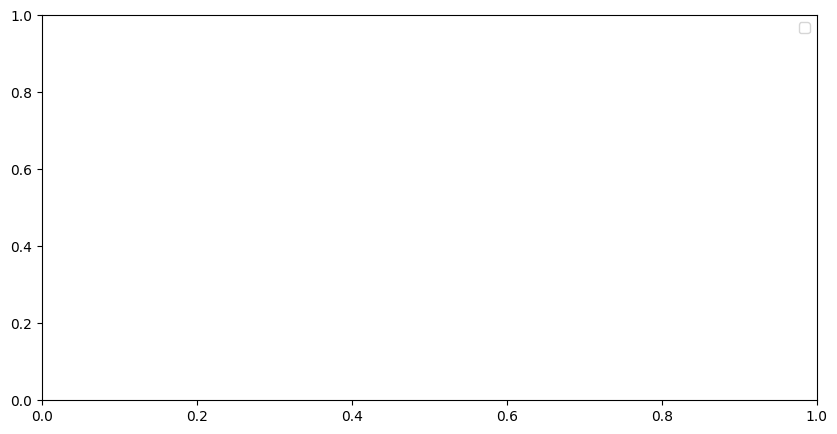

In [194]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    train.loc[train.bank_account==1,"age_of_respondent"],
    label="Has Account"
)

sns.kdeplot(
    train.loc[train.bank_account==0,"age_of_respondent"],
    label="No Account"
)

plt.legend()
plt.show()

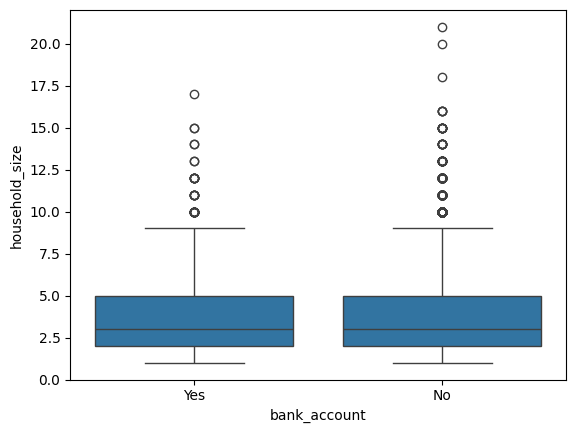

In [195]:
sns.boxplot(
    x="bank_account",
    y="household_size",
    data=train
)
plt.show()

In [196]:
pd.crosstab(
 [train.country,train.cellphone_access],
 train.bank_account,
 normalize='index'
)*100

bank_account                      No        Yes
country  cellphone_access                      
Kenya    No                95.167576   4.832424
         Yes               69.508882  30.491118
Rwanda   No                98.721400   1.278600
         Yes               86.425714  13.574286
Tanzania No                99.512012   0.487988
         Yes               84.984833  15.015167
Uganda   No                98.430141   1.569859
         Yes               88.319672  11.680328

In [197]:
pd.crosstab(
 [train.education_level,train.gender_of_respondent],
 train.bank_account,
 normalize='index'
)*100

bank_account                                                 No        Yes
education_level                 gender_of_respondent                      
No formal education             Female                96.862253   3.137747
                                Male                  94.277108   5.722892
Other/Dont know/RTA             Female                68.181818  31.818182
                                Male                  69.230769  30.769231
Primary education               Female                93.650794   6.349206
                                Male                  88.407691  11.592309
Secondary education             Female                81.029083  18.970917
                                Male                  71.881288  28.118712
Tertiary education              Female                53.460208  46.539792
                                Male                  44.386874  55.613126
Vocational/Specialised training Female                50.118765  49.881235
                                Male                  35.078534  64.921466

In [198]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train["bank_account"] = le.fit_transform(
    train["bank_account"]
)

In [199]:
def preprocessing_data(data):

    data = data.copy()

    # engineered features
    data["age_house_ratio"] = (
        data["age_of_respondent"] /
        (data["household_size"] + 1)
    )

    data["age_house_interaction"] = (
        data["age_of_respondent"] *
        data["household_size"]
    )

    data["is_young"] = (
        data["age_of_respondent"] < 30
    ).astype(int)

    data["large_household"] = (
        data["household_size"] >= 5
    ).astype(int)


    # age bins
    data["age_bin"] = pd.cut(
        data["age_of_respondent"],
        bins=[15,25,35,50,100],
        labels=[
            "young",
            "adult",
            "mid",
            "senior"
        ]
    )


    # -------- Domain-driven features from EDA --------

    # 1 formal employment flag
    formal_jobs = [
        "Formally employed Private",
        "Formally employed Government"
    ]

    data["formal_job"] = data["job_type"].isin(
        formal_jobs
    ).astype(int)


    # 2 education grouped
    high_ed = [
        "Secondary education",
        "Tertiary education",
        "Vocational/Specialised training"
    ]

    data["high_education"] = data[
        "education_level"
    ].isin(high_ed).astype(int)


    # 3 urban + cellphone combo
    data["urban_mobile"] = (
        (data["location_type"]=="Urban") &
        (data["cellphone_access"]=="Yes")
    ).astype(int)


    # 4 prime working age
    data["prime_age"] = (
        (data["age_of_respondent"]>=25) &
        (data["age_of_respondent"]<=50)
    ).astype(int)


    # 5 female head interaction
    data["female_head"] = (
        (data["gender_of_respondent"]=="Female") &
        (data["relationship_with_head"]=="Head of Household")
    ).astype(int)



    # -------- NEW FEATURE ENGINEERING --------

    # 6 mobile + education signal
    data["educated_mobile"] = (
        (data["cellphone_access"]=="Yes") &
        (data["high_education"]==1)
    ).astype(int)


    # 7 elite profile
    data["elite_profile"] = (
        (data["formal_job"]==1) &
        (data["high_education"]==1)
    ).astype(int)


    # 8 Kenya signal
    data["is_kenya"] = (
        data["country"]=="Kenya"
    ).astype(int)


    # 9 prime age + mobile
    data["prime_mobile"] = (
        (data["prime_age"]==1) &
        (data["cellphone_access"]=="Yes")
    ).astype(int)


    # 10 nonlinear age
    data["age_squared"] = (
        data["age_of_respondent"] ** 2
    )


    # 11 dependency burden
    data["dependency_ratio"] = (
        data["household_size"] /
        (data["age_of_respondent"] + 1)
    )


    # one-hot categorical
    categ = [
        "relationship_with_head",
        "marital_status",
        "education_level",
        "job_type",
        "country",
        "age_bin"
    ]

    data = pd.get_dummies(
        data,
        columns=categ
    )


    # label encoding binary categories
    for col in [
        "location_type",
        "cellphone_access",
        "gender_of_respondent"
    ]:
        data[col] = LabelEncoder().fit_transform(
            data[col]
        )


    # remove id
    data = data.drop(
        ["uniqueid"],
        axis=1
    )

    return data

In [200]:
X_train = train.drop(
    ["bank_account"],
    axis=1
)

y_train = train["bank_account"]

processed_train = preprocessing_data(
    X_train
)

processed_test = preprocessing_data(
    test
)

In [201]:
print(processed_train.shape)
print(processed_test.shape)

(23524, 56)
(10086, 56)


In [202]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_split, y_val = train_test_split(
    processed_train,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

In [203]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.025,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=1,
    gamma=1,
    random_state=42,
    eval_metric='logloss'
)

In [204]:
xgb_model.fit(
    X_train, y_train_split,
    eval_set=[(X_val, y_val)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.025, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [205]:
from sklearn.metrics import accuracy_score

val_preds = xgb_model.predict(X_val)

error_rate = 1 - accuracy_score(y_val, val_preds)

print("Validation Error Rate:", error_rate)

Validation Error Rate: 0.10624734381640455


In [206]:
test.bank_account = xgb_model.predict(processed_test)

In [207]:
# Create submission DataFrame
submission = pd.DataFrame({
    "uniqueid": test["uniqueid"] + " x " + test["country"],
    "bank_account": test.bank_account
})



In [210]:
# show sample
submission.sample(5)

,uniqueid,bank_account
4657,uniqueid_10792 x Rwanda,0
7770,uniqueid_8045 x Tanzania,0
3787,uniqueid_9922 x Rwanda,0
8108,uniqueid_8383 x Tanzania,0
9619,uniqueid_2536 x Uganda,0


In [212]:
# Create submission csv file
submission.to_csv('fo6submission.csv', index=False)
